# Image Classification with Hotswappable Architectures

This notebook trains image classifiers with **configurable architectures** (CNN or MLP) on various datasets, then evaluates performance with metrics and visualizations.

**Supported architectures:**
- **CNN**: Convolutional Neural Network with multiple conv blocks
- **MLP**: Multi-Layer Perceptron (fully connected layers)

**Supported datasets:**
- **CIFAR-10**: 32x32 color images in 10 classes (airplanes, cars, birds, etc.)
- **MNIST**: 28x28 grayscale handwritten digits (0-9)
- **Fashion-MNIST**: 28x28 grayscale clothing items (t-shirts, trousers, shoes, etc.)

The model architecture automatically adapts to the input dimensions and number of channels for each dataset.

Now we'll import the necessary libraries and enable autoreload so changes to our shared library are automatically loaded.

In [2]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as L
import wandb
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# Import shared utilities from local package
from aiml_notebooks import (
    log_gradients, log_model_weights, log_gradient_flow,
    create_trainer, create_dataset, create_dataloaders,
    show_image_grid_normalized, plot_confusion_matrix,
    get_dataset_config,
    log_confusion_matrix_callback, log_prediction_grid_callback,
    create_image_classifier,  # Factory for CNN/MLP classifiers
)

# Enable autoreload for hot reloading of library changes
%load_ext autoreload
%autoreload 2

print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {L.__version__}")

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. 

PyTorch: 2.9.0
Lightning: 2.5.5


In [ ]:
# Configuration (Base defaults - can be overridden by papermill parameters)
CONFIG = {
    # Data
    'dataset': 'mnist',              # Dataset to use: 'cifar10', 'mnist', or 'fashionmnist'
    'seed': 42,                      # Random seed for reproducibility
    'batch_size': 128,               # Number of examples per training batch
    'num_workers': 4,                # Number of parallel data loading workers
    
    # Training
    'max_epochs': 50,                # Number of complete passes through training data
    'log_every_n_steps': 20,         # How often to log training metrics
    
    # Model Architecture
    'classifier_type': 'mlp',        # Classifier architecture: 'cnn' or 'mlp'
    'dropout': 0.5,                  # Dropout rate to prevent overfitting
    'learning_rate': 1e-3,           # Step size for optimizer (0.001)
    
    # MLP-specific parameters (used when classifier_type='mlp')
    'mlp_hidden_sizes': [512, 256, 128], # List of hidden layer sizes for MLP
    
    # CNN-specific parameters (used when classifier_type='cnn')
    'cnn_num_conv_layers': 3,        # Number of convolutional blocks
    'cnn_base_channels': 32,         # Number of channels in first conv layer (doubles each block)
    
    # Weights & Biases
    'wandb_project': "classification-image",  # W&B project name (auto-detected from notebook filename)
    'wandb_run_name': None,          # Optional run name (None = auto-generated)
}

# Set random seeds
L.seed_everything(CONFIG['seed'])

Seed set to 42
Seed set to 42


42

Now we'll use the dataset factory to load the selected dataset:
- **MNIST**: 70,000 28x28 grayscale handwritten digits (60k train, 10k test)
- **Fashion-MNIST**: 70,000 28x28 grayscale clothing images in 10 classes (60k train, 10k test)
- **CIFAR-10**: 60,000 32x32 color images in 10 classes (50k train, 10k test)

In [4]:
# Get dataset configuration using shared library function
dataset_config = get_dataset_config(CONFIG['dataset'])
class_names = dataset_config['classes']
num_classes = len(class_names)
num_channels = dataset_config['num_channels']
image_size = dataset_config['image_size']

# Define data transforms (normalization and data augmentation for training)
# Training transforms with data augmentation
if CONFIG['dataset'] == 'cifar10':
    # CIFAR-10 specific augmentation
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(image_size, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(dataset_config['mean'], dataset_config['std'])
    ])
elif CONFIG['dataset'] in ['mnist', 'fashionmnist']:
    # MNIST/Fashion-MNIST specific augmentation
    train_transform = transforms.Compose([
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(dataset_config['mean'], dataset_config['std'])
    ])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(dataset_config['mean'], dataset_config['std'])
])

# Load dataset using the factory (returns train, test)
train_dataset, test_dataset = create_dataset(
    dataset_id=CONFIG['dataset'],
    train_transform=train_transform,
    test_transform=test_transform
)

print(f"Dataset: {dataset_config['name']}")
print(f"Image size: {image_size}x{image_size}x{num_channels}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes ({num_classes}): {', '.join(class_names)}")

Dataset: MNIST
Image size: 28x28x1
Train samples: 60000
Test samples: 10000
Classes (10): 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


Now we'll use the dataloader factory to create batched, shuffled loaders for training and testing.

The model will automatically log visualizations (confusion matrices and prediction grids) to W&B at the end of each validation epoch.

In [5]:
# Create data loaders using the factory
train_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=test_dataset,  # Using test set as val set for this notebook
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    use_collate_fn=False,  # Vision datasets don't need padding
    pin_memory=True
)

print(f"✓ Data loaders created (batch_size={CONFIG['batch_size']})")

✓ Data loaders created (batch_size=128)


Now we'll create our classifier using the configuration. The architecture is **hotswappable** - simply change `classifier_type` in the config to switch between CNN and MLP.

**CNN Architecture:**
- Multiple convolutional blocks (Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU → MaxPool)
- Fully connected classifier with dropout

**MLP Architecture:**
- Flatten input image
- Multiple fully connected layers with BatchNorm, ReLU, and dropout
- Output layer for classification

In [6]:
# Create the classifier using the factory function
# This automatically selects CNN or MLP based on CONFIG['classifier_type']
model = create_image_classifier(
    classifier_type=CONFIG['classifier_type'],
    num_classes=num_classes,
    in_channels=num_channels,
    input_size=image_size,
    learning_rate=CONFIG['learning_rate'],
    class_names=class_names,
    dataset_mean=dataset_config['mean'],
    dataset_std=dataset_config['std'],
    # CNN-specific parameters (ignored if classifier_type='mlp')
    cnn_num_conv_layers=CONFIG['cnn_num_conv_layers'],
    cnn_base_channels=CONFIG['cnn_base_channels'],
    # MLP-specific parameters (ignored if classifier_type='cnn')
    mlp_hidden_sizes=CONFIG['mlp_hidden_sizes'],
    # Common parameters
    dropout=CONFIG['dropout'],
)

print(f"Initialized {CONFIG['classifier_type'].upper()} for {dataset_config['name']}")
print(f"Input: {num_channels} x {image_size} x {image_size}")
print(f"Output: {num_classes} classes")
if CONFIG['classifier_type'] == 'cnn':
    print(f"Architecture: {CONFIG['cnn_num_conv_layers']} convolutional blocks, base_channels={CONFIG['cnn_base_channels']}")
else:
    print(f"Architecture: MLP with hidden layers {CONFIG['mlp_hidden_sizes']}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Initialized CNN for MNIST
Input: 1 x 28 x 28
Output: 10 classes
Architecture: 3 convolutional blocks, base_channels=32
Total parameters: 882,794


Now we'll train the model using PyTorch Lightning's Trainer with W&B logging.

wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
HPU available: False, using: 0 HPUs

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | architecture | CNNArchitecture  | 882 K  | train
1 | criterion    | CrossEntropyLoss | 0      | train
----------------------------------------------------------
882 K     Trainable params
0         Non-trainable params
882 K     Total params
3

Created W&B run: snowy-universe-5


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.war

...

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
`Trainer.fit` stopped: `max_epochs=50` reached.
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


✓ Training complete. View metrics and visualizations in W&B dashboard.


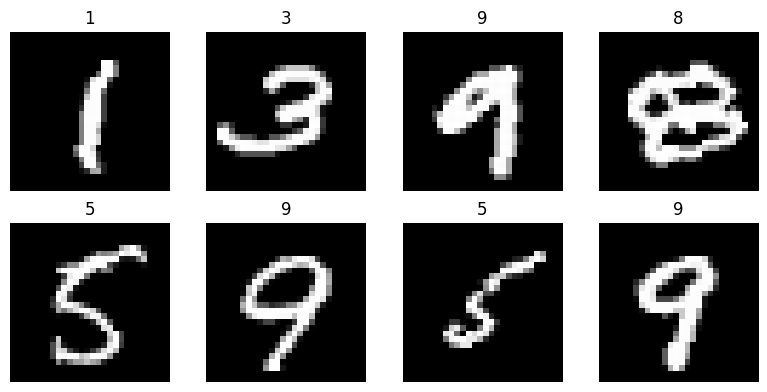

In [7]:
# Train the model (W&B logger created automatically)
trainer = create_trainer(
    max_epochs=CONFIG['max_epochs'],
    log_every_n_steps=CONFIG['log_every_n_steps'],
    wandb_project=CONFIG['wandb_project'],
    wandb_run_name=CONFIG['wandb_run_name'],
    wandb_config=CONFIG,
    model=model
)
trainer.fit(model, train_loader, test_loader)

# Log sample images to W&B
sample_images, sample_labels = next(iter(train_loader))
fig = plt.figure(figsize=(8, 4))
show_image_grid_normalized(
    images=sample_images[:8],
    mean=dataset_config['mean'],
    std=dataset_config['std'],
    labels=sample_labels[:8],
    class_names=class_names,
    nrows=2,
    ncols=4,
    figsize=(8, 4)
)
wandb.log({'sample_training_images': wandb.Image(plt.gcf())})
plt.close(fig)

print("✓ Training complete. View metrics and visualizations in W&B dashboard.")

Now we'll evaluate the model on the test set. Note that confusion matrices and prediction grids were already logged to W&B during validation epochs. Below we'll compute the final test accuracy.

In [8]:
# Test the model
test_results = trainer.test(model, test_loader, verbose=False)

# Calculate and display test accuracy
test_acc = test_results[0]['test_acc']
print(f"\n{'='*50}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"{'='*50}\n")

# Log to W&B
wandb.log({'test_accuracy': test_acc * 100})

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]


Test Accuracy: 99.59%

